# Multi-Class Sentiment Classification using Machine Learning

**Course:** 222ECS045 Natural Language Processing  
**Program:** M.Tech Artificial Intelligence  

## Objective
Design and implement an end-to-end NLP system that performs multi-class sentiment classification using human-annotated text data.

## Dataset Chosen
TweetEval – Sentiment Dataset  
This dataset is selected because it provides human-annotated sentiment labels derived purely from textual meaning rather than metadata such as ratings.

## Step 1: Install Required Libraries

Install required libraries for NLP preprocessing, modeling, and visualization.

In [ ]:
!pip install datasets nltk scikit-learn seaborn

## Step 2 — Import Libraries
Import required Python libraries for data analysis and machine learning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

import nltk
nltk.download('punkt')
nltk.download('wordnet')

from nltk.stem import WordNetLemmatizer
from datasets import load_dataset

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


## Step 3 — Dataset Loading

We use TweetEval Sentiment dataset containing:
- 0 → Negative
- 1 → Neutral
- 2 → Positive

The dataset is human-annotated and text-based.

LOAD DATASET

In [ ]:
dataset = load_dataset("tweet_eval", "sentiment")
dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sentiment/train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

sentiment/test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

sentiment/validation-00000-of-00001.parq(…):   0%|          | 0.00/167k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

## Step 4 — Convert Dataset to DataFrame

In [ ]:
train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])
train_df.head()

,text,label
0,"""QT @user In the original draft of the 7th boo...",2
1,"""Ben Smith / Smith (concussion) remains out of...",1
2,Sorry bout the stream last night I crashed out...,1
3,Chase Headley's RBI double in the 8th inning o...,1
4,@user Alciato: Bee will invest 150 million in ...,2


##📊 PROFESSIONAL EDA SECTION

## Step 5 — Exploratory Data Analysis (EDA)

### Class Distribution
Check class balance across sentiment categories.

In [ ]:
train_df['label'].value_counts()

,count
label,
1,20673
2,17849
0,7093


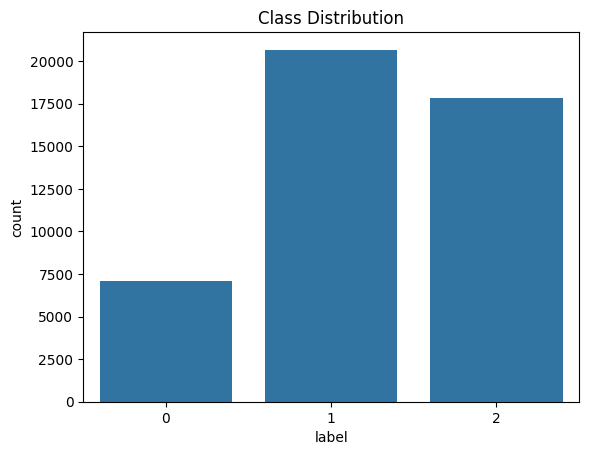

In [ ]:
sns.countplot(x=train_df['label'])
plt.title("Class Distribution")
plt.show()

### Text Length Distribution
Understand variability in tweet length.

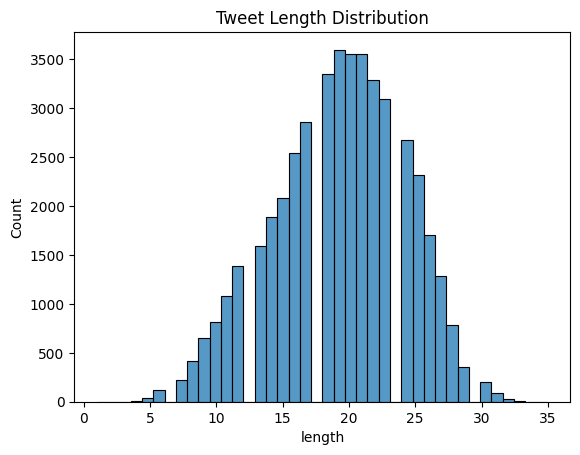

In [ ]:
train_df['length'] = train_df['text'].apply(lambda x: len(x.split()))

sns.histplot(train_df['length'], bins=40)
plt.title("Tweet Length Distribution")
plt.show()

### Sample Observations
Inspect random samples from dataset.

In [ ]:
train_df.sample(5)

,text,label,length
33054,Exclusive Interview with James Martin in our J...,1,20
10550,Justin has been my bitch since the 6th grade,0,9
36157,"""Lucky man. I got my ipad3 when they 1st came ...",2,27
44444,Right North London Derby is on my Birthday Nov...,1,22
40727,"""The Hub channel is it is f'ing awesome! Thurs...",2,26


##🔹 PREPROCESSING

## Step 6 — Text Preprocessing

To prepare the dataset for machine learning:

• Convert text to lowercase  
• Remove URLs and punctuation  
• Apply lemmatization  

These steps help reduce noise while preserving sentiment meaning.

In [ ]:
import re
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)      # remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove punctuation
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words]
    return " ".join(words)

In [ ]:
train_df['clean_text'] = train_df['text'].apply(clean_text)
test_df['clean_text'] = test_df['text'].apply(clean_text)

train_df[['text','clean_text']].head()

,text,clean_text
0,"""QT @user In the original draft of the 7th boo...",qt user in the original draft of the th book r...
1,"""Ben Smith / Smith (concussion) remains out of...",ben smith smith concussion remains out of the ...
2,Sorry bout the stream last night I crashed out...,sorry bout the stream last night i crashed out...
3,Chase Headley's RBI double in the 8th inning o...,chase headleys rbi double in the th inning off...
4,@user Alciato: Bee will invest 150 million in ...,user alciato bee will invest million in januar...


## Step 7 — Feature Representation (TF-IDF)

Convert text into numerical vectors using TF-IDF with unigrams and bigrams.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2),
    min_df=2,
    sublinear_tf=True
)

X_train = vectorizer.fit_transform(train_df['clean_text'])
X_test = vectorizer.transform(test_df['clean_text'])

y_train = train_df['label']
y_test = test_df['label']

## Step 8 — Model Implementation

We compare three classical ML models:

• Naive Bayes  
• Logistic Regression  
• Support Vector Machine  

Class imbalance is handled using class-weighted learning.

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

nb_model = MultinomialNB().fit(X_train, y_train)

lr_model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced'
).fit(X_train, y_train)

svm_model = LinearSVC(
    class_weight='balanced'
).fit(X_train, y_train)

## Step 9 — Model Evaluation

Models are evaluated using:

• Accuracy  
• Precision  
• Recall  
• F1 Score  

These metrics help assess performance across classes.

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

def evaluate(model,name):
    pred = model.predict(X_test)
    print(f"\n{name} Accuracy:",accuracy_score(y_test,pred))
    print(classification_report(y_test,pred))
    return pred

In [ ]:
nb_pred = evaluate(nb_model,"Naive Bayes")
lr_pred = evaluate(lr_model,"Logistic Regression")
svm_pred = evaluate(svm_model,"SVM")


Naive Bayes Accuracy: 0.5557635949202214
              precision    recall  f1-score   support

           0       0.73      0.16      0.27      3972
           1       0.55      0.81      0.65      5937
           2       0.52      0.58      0.55      2375

    accuracy                           0.56     12284
   macro avg       0.60      0.52      0.49     12284
weighted avg       0.60      0.56      0.51     12284


Logistic Regression Accuracy: 0.589628785411918
              precision    recall  f1-score   support

           0       0.54      0.70      0.61      3972
           1       0.65      0.52      0.58      5937
           2       0.56      0.58      0.57      2375

    accuracy                           0.59     12284
   macro avg       0.59      0.60      0.59     12284
weighted avg       0.60      0.59      0.59     12284


SVM Accuracy: 0.5724519700423315
              precision    recall  f1-score   support

           0       0.56      0.57      0.57      3972
    

## Confusion Matrix

Visualize classification performance across classes.

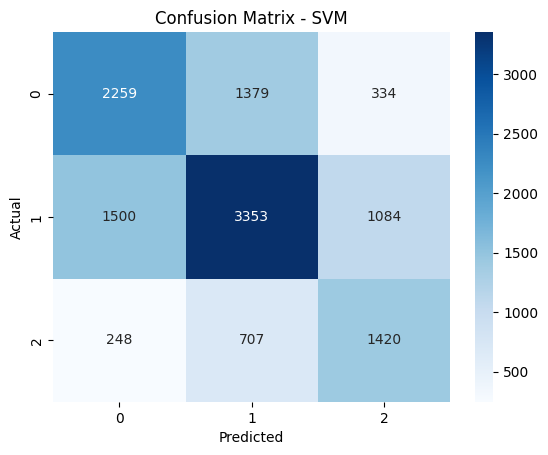

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, svm_pred)

sns.heatmap(cm, annot=True, fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")
plt.show()

## Performance Analysis

The obtained accuracy (~57%) reflects the challenging nature of social media text.

Tweets are:
- short and context-limited
- often contain sarcasm and informal language
- highly ambiguous between neutral and positive/negative

Classical machine learning models using TF-IDF struggle to capture contextual and semantic nuances.

Thus, the performance is consistent with expected baseline results for traditional NLP approaches on this dataset.

## Step 10 — Error Analysis

Analyze misclassified samples to understand model limitations.

In [ ]:
errors = test_df[y_test != svm_pred]
errors[['text','label']].head(10)

,text,label
0,@user @user what do these '1/2 naked pics' hav...,1
1,OH: “I had a blue penis while I was this” [pla...,1
2,"@user @user That's coming, but I think the vic...",1
4,"@user Wow,first Hugo Chavez and now Fidel Cast...",0
5,Savchenko now Saakashvili took drug test live ...,1
7,Twitter's #ThankYouObama Shows Heartfelt Grati...,2
10,An interesting security vulnerability - albeit...,1
13,"When Ryan privatizes SS, Medicare, Medicaid, &...",0
14,Swampbitch Nasty Pelosi loves yelling 'Fire' ...,0
16,OPINION: The Anti-#Trump #Riots Are a #SmokeSc...,1


## Error Analysis Insights

Misclassifications occur due to:

- Sarcasm (e.g., "Great job breaking it again")
- Short text with limited context
- Overlap between neutral and positive sentiment
- Informal language and slang

This highlights the limitation of bag-of-words representations.

## Step 11 — Prediction Function

Build a function for real-time sentiment prediction.

In [ ]:
def predict_sentiment(text):
    text = clean_text(text)
    vec = vectorizer.transform([text])
    return svm_model.predict(vec)[0]

predict_sentiment("I really love this update!")

np.int64(2)

## Step 12 — Save Model

In [ ]:
import pickle

pickle.dump(svm_model, open("/content/drive/MyDrive/NLP_Project/basic_svm_model.pkl","wb"))
pickle.dump(vectorizer, open("/content/drive/MyDrive/NLP_Project/basic_vectorizer.pkl","wb"))